In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from sklearn.metrics import r2_score
from scipy.special import rel_entr

from biological_fuzzy_logic_networks.manuscripts_functions.colors import models_dict
from biological_fuzzy_logic_networks.manuscripts_functions.metrics import compute_scalar_mmd, wasserstein_distance

In [2]:
fontsize = 12

In [3]:
sns.set_theme(font="Arial", style="ticks", rc={"font.size": fontsize,"axes.titlesize":fontsize,"axes.labelsize":fontsize, 
                                               "xtick.labelsize": fontsize, "ytick.labelsize": fontsize, "legend.fontsize": fontsize})
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.size'] = fontsize


In [4]:
test_input = False
train_input = True
test_y = False
train_y = True

base_dir = "/dccstor/ipc1/CAR/BFN/Model/Noise/"
noise_range = 4
n_runs = 5

markers = [
        "mek12",
        "erk12",
        "mkk4",
        "jnk12",
        "ikk",
        "ikb",
        "ras",
        "map3k7",
        "igf1",
        "pi3k",
        "il1a",
        "map3k1",
        "tgfa",
        "tnfa",
        "akt",
        "p38",
        "hsp27",
    ]

output_markers = list(set(markers).difference(set(["igf1", "tgfa", "tnfa", "il1a"])))


In [5]:
def compute_MMD(data, markers=output_markers):
    data["cell_id"] = len(data['marker'].unique())*[i for i in range(int(len(data)/len(data["marker"].unique())))] 
    
    pred = data[["cell_id", "marker", "pred"]]
    pred = pred.set_index("cell_id").pivot(columns="marker")
    
    
    true = data[["cell_id", "marker", "true"]]
    true = true.set_index("cell_id").pivot(columns="marker")
    mmd = compute_scalar_mmd(true, pred)
    
    return mmd


def compute_wasserstein(data, markers=output_markers):
    data["cell_id"] = len(data['marker'].unique())*[i for i in range(int(len(data)/len(data["marker"].unique())))] 
    
    pred = data[["cell_id", "marker", "pred"]]
    pred = pred.set_index("cell_id").pivot(columns="marker")
    
    
    true = data[["cell_id", "marker", "true"]]
    true = true.set_index("cell_id").pivot(columns="marker")
    emd = wasserstein_distance(true, pred)
    
    return emd

def compute_R2(data):
    out = r2_score(data["true"], data['pred'])
    return out

# Baseline without noise

In [6]:
no_noise_outputs = []
no_noise_trues = []
for i in range(n_runs):
    
    run_output = pd.read_csv(os.path.join(base_dir, "Error_sd_0", f"{i+1}_unperturbed.csv"), index_col=1)
    run_output = run_output.rename(columns={"Unnamed: 0": "model"})
    run_output["noise_sd"] = 0
    run_output["repeat"] = i+1
    
    no_noise_outputs.append(run_output[run_output["model"]!="teacher_true"])
    no_noise_trues.append(run_output[run_output["model"]=="teacher_true"])

no_noise_output = pd.concat(no_noise_outputs).reset_index(drop=False)
no_noise_true = pd.concat(no_noise_trues).reset_index(drop=False).drop("model", axis=1)

no_noise_pred_long = no_noise_output.melt(id_vars=["index", "noise_sd", "repeat", "model"], var_name="marker", value_name="pred")
no_noise_true_long = no_noise_true.melt(id_vars=["index", "noise_sd", "repeat"], var_name="marker", value_name="true")

no_noise_df = no_noise_pred_long.merge(no_noise_true_long, on=["index", "repeat", "marker", "noise_sd"]).dropna()
no_noise_df = no_noise_df.drop("index", axis=1)
no_noise_df["error"] = (no_noise_df["true"] - no_noise_df["pred"])
no_noise_df["sq_err"] = no_noise_df["error"]**2
no_noise_df["abs_error"] = abs(no_noise_df["error"])
no_noise_df = no_noise_df[no_noise_df["model"]!="teacher_true"]
no_noise_df[(no_noise_df['marker']=="mek12")&(no_noise_df["model"]=="student_same_input")]

,noise_sd,repeat,model,marker,pred,true,error,sq_err,abs_error
0,0,1,student_same_input,mek12,0.554042,0.554040,-1.557668e-06,2.426328e-12,1.557668e-06
6,0,1,student_same_input,mek12,0.409095,0.409097,2.238407e-06,5.010464e-12,2.238407e-06
12,0,1,student_same_input,mek12,0.027674,0.027665,-9.423983e-06,8.881145e-11,9.423983e-06
18,0,1,student_same_input,mek12,0.115765,0.115753,-1.169206e-05,1.367042e-10,1.169206e-05
24,0,1,student_same_input,mek12,0.042372,0.042361,-1.130669e-05,1.278412e-10,1.130669e-05
...,...,...,...,...,...,...,...,...,...
59970,0,5,student_same_input,mek12,0.456748,0.456782,3.421404e-05,1.170601e-09,3.421404e-05
59976,0,5,student_same_input,mek12,0.999999,0.999999,-7.257478e-09,5.267099e-17,7.257478e-09
59982,0,5,student_same_input,mek12,0.962674,0.962676,1.697318e-06,2.880888e-12,1.697318e-06
59988,0,5,student_same_input,mek12,0.216271,0.216288,1.786218e-05,3.190576e-10,1.786218e-05


In [7]:
no_noise_df

,noise_sd,repeat,model,marker,pred,true,error,sq_err,abs_error
0,0,1,student_same_input,mek12,0.554042,0.55404,-1.557668e-06,2.426328e-12,1.557668e-06
1,0,1,student_random_input,mek12,0.999997,0.55404,-4.459567e-01,1.988774e-01,4.459567e-01
2,0,1,nohill_same_input,mek12,0.429020,0.55404,1.250198e-01,1.562995e-02,1.250198e-01
3,0,1,nohill_random_input,mek12,0.122270,0.55404,4.317700e-01,1.864253e-01,4.317700e-01
4,0,1,lm_same_input,mek12,0.570864,0.55404,-1.682348e-02,2.830295e-04,1.682348e-02
...,...,...,...,...,...,...,...,...,...
779995,0,5,student_random_input,hsp27,1.000000,1.00000,3.115484e-08,9.706239e-16,3.115484e-08
779996,0,5,nohill_same_input,hsp27,0.481639,1.00000,5.183606e-01,2.686977e-01,5.183606e-01
779997,0,5,nohill_random_input,hsp27,0.117377,1.00000,8.826233e-01,7.790239e-01,8.826233e-01
779998,0,5,lm_same_input,hsp27,0.910243,1.00000,8.975718e-02,8.056352e-03,8.975718e-02


In [8]:
no_noise_grouped = no_noise_df.groupby(["noise_sd", "repeat", "model", "marker"]).mean()
no_noise_grouped["R2"] = no_noise_df.groupby(["noise_sd", "repeat", "model", "marker"]).apply(compute_R2)
no_noise_grouped = no_noise_grouped.reset_index(drop=False)
no_noise_grouped = no_noise_grouped.rename(columns={"sq_err": "MSE"})
no_noise_grouped

,noise_sd,repeat,model,marker,pred,true,error,MSE,abs_error,R2
0,0,1,lm_random_input,akt,0.919208,0.922444,0.003236,5.237776e-02,0.162093,-0.486424
1,0,1,lm_random_input,erk12,0.347926,0.344646,-0.003280,3.487900e-01,0.488932,-0.796082
2,0,1,lm_random_input,hsp27,0.423563,0.435443,0.011880,4.138803e-01,0.529209,-0.782818
3,0,1,lm_random_input,ikb,0.881296,0.888853,0.007557,1.012894e-01,0.236169,-0.393203
4,0,1,lm_random_input,ikk,0.869082,0.875773,0.006691,9.244464e-02,0.233756,-0.493911
...,...,...,...,...,...,...,...,...,...,...
385,0,5,student_same_input,mek12,0.506388,0.506399,0.000011,2.798899e-10,0.000011,1.000000
386,0,5,student_same_input,mkk4,0.482602,0.482360,-0.000243,4.066260e-06,0.000976,0.999979
387,0,5,student_same_input,p38,0.453864,0.453708,-0.000156,9.215290e-06,0.001661,0.999955
388,0,5,student_same_input,pi3k,0.879213,0.878968,-0.000245,6.141795e-06,0.001196,0.999864


In [9]:
no_noise_mmd = no_noise_df.groupby(["noise_sd", "repeat", "model"]).mean(numeric_only=True)
no_noise_mmd["MMD"] = no_noise_df.groupby(["noise_sd", "repeat", "model"]).apply(compute_MMD)
no_noise_mmd["EMD"] = no_noise_df.groupby(["noise_sd", "repeat", "model"]).apply(compute_wasserstein)


2025-03-11 05:10:44.156089: W external/xla/xla/service/gpu/nvptx_compiler.cc:679] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.5.40). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [10]:
no_noise_mmd

pred      true     error  \
noise_sd repeat model                                                
0        1      lm_random_input       0.604071  0.610336  0.006265   
                lm_same_input         0.611189  0.610336 -0.000853   
                nohill_random_input   0.465983  0.610336  0.144353   
                nohill_same_input     0.474002  0.610336  0.136334   
                student_random_input  0.600403  0.610336  0.009933   
                student_same_input    0.610408  0.610336 -0.000073   
         2      lm_random_input       0.618957  0.632803  0.013846   
                lm_same_input         0.634919  0.632803 -0.002116   
                nohill_random_input   0.463621  0.632803  0.169182   
                nohill_same_input     0.475214  0.632803  0.157589   
                student_random_input  0.615869  0.632803  0.016935   
                student_same_input    0.632967  0.632803 -0.000163   
         3      lm_random_input       0.571890  0.569498 -0.002392   
                lm_same_input         0.570187  0.569498 -0.000689   
                nohill_random_input   0.465897  0.569498  0.103601   
                nohill_same_input     0.461845  0.569498  0.107653   
                student_random_input  0.571714  0.569498 -0.002216   
                student_same_input    0.569593  0.569498 -0.000095   
         4      lm_random_input       0.587276  0.575067 -0.012209   
                lm_same_input         0.577149  0.575067 -0.002082   
                nohill_random_input   0.462370  0.575067  0.112697   
                nohill_same_input     0.459620  0.575067  0.115447   
                student_random_input  0.585355  0.575067 -0.010289   
                student_same_input    0.575101  0.575067 -0.000035   
         5      lm_random_input       0.589923  0.595220  0.005297   
                lm_same_input         0.598720  0.595220 -0.003500   
                nohill_random_input   0.464442  0.595220  0.130779   
                nohill_same_input     0.469686  0.595220  0.125534   
                student_random_input  0.589847  0.595220  0.005373   
                student_same_input    0.595303  0.595220 -0.000083   

                                            sq_err  abs_error           MMD  \
noise_sd repeat model                                                         
0        1      lm_random_input       2.378810e-01   0.373355  2.582962e-02   
                lm_same_input         2.750824e-02   0.130926  2.351703e-02   
                nohill_random_input   2.386160e-01   0.369972  8.423555e-02   
                nohill_same_input     6.819872e-02   0.164337  8.125910e-02   
                student_random_input  2.677158e-01   0.352927  4.816055e-04   
                student_same_input    2.068262e-06   0.000420  8.692344e-07   
         2      lm_random_input       2.658165e-01   0.407751  2.551660e-02   
                lm_same_input         3.002352e-02   0.141402  2.375246e-02   
                nohill_random_input   2.589736e-01   0.391259  9.700037e-02   
                nohill_same_input     8.160432e-02   0.176798  9.154094e-02   
                student_random_input  2.955328e-01   0.389648  5.878061e-04   
                student_same_input    3.006111e-06   0.000603  5.935629e-07   
         3      lm_random_input       2.530141e-01   0.396273  2.462133e-02   
                lm_same_input         3.133222e-02   0.140282  2.560711e-02   
                nohill_random_input   2.379196e-01   0.372568  5.614244e-02   
                nohill_same_input     5.034668e-02   0.138246  5.990286e-02   
                student_random_input  2.851478e-01   0.382480  4.136885e-04   
                student_same_input    8.471992e-07   0.000315  2.657374e-07   
         4      lm_random_input       2.702686e-01   0.413337  2.157732e-02   
                lm_same_input         3.076188e-02   0.140718  2.401003e-02   
                nohill_random_input   2.437521e-01   0.378369  

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
/tmp/ipykernel_2398327/544725045.py:19: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_MSE_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/544725045.py:19: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_MSE_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/544725045.py:19: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated sinc

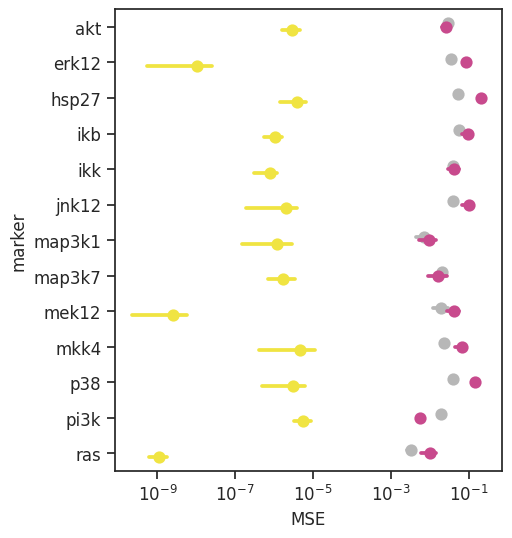

/tmp/ipykernel_2398327/544725045.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_R2_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/544725045.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_R2_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/544725045.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_R2_pointplot.pdf", bbox_in

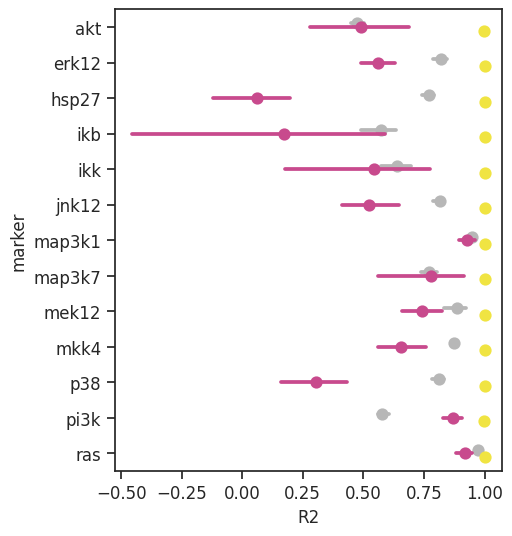

In [11]:
# temp = no_noise_grouped[no_noise_grouped["model"].isin(["student_same_input", "nohill_same_input", "lm_same_input"])]
# sns.boxplot(data=temp, y="marker", x="MSE", hue="model", palette=models_dict)
# plt.xscale('log')
# plt.legend([], [], frameon=False)
# plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_MSE.pdf", bbox_inches="tight")
# plt.show()

# temp = no_noise_grouped[no_noise_grouped["model"].isin(["student_same_input", "nohill_same_input", "lm_same_input"])]
# sns.boxplot(data=temp, y="marker", x="R2", hue="model", palette=models_dict)
# plt.legend([], [], frameon=False)
# plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_R2.pdf", bbox_inches="tight")
# plt.show()

temp = no_noise_grouped[no_noise_grouped["model"].isin(["student_same_input", "nohill_same_input", "lm_same_input"])]
plt.figure(figsize=(5,6))
sns.pointplot(data=temp, y="marker", x="MSE", hue="model", palette=models_dict, linestyles="none", dodge=0.2)
plt.xscale('log')
plt.legend([], [], frameon=False)
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_MSE_pointplot.pdf", bbox_inches="tight")
plt.show()

temp = no_noise_grouped[no_noise_grouped["model"].isin(["student_same_input", "nohill_same_input", "lm_same_input"])]
plt.figure(figsize=(5,6))
sns.pointplot(data=temp, y="marker", x="R2", hue="model", palette=models_dict, linestyles="none", dodge=0.2)
plt.legend([], [], frameon=False)
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/No_noise_same_input_R2_pointplot.pdf", bbox_inches="tight")
plt.show()

# Load experiments

In [12]:
experiment_name = []

if train_input:
    experiment_name.append("tri")
if train_y:
    experiment_name.append("try")
if test_input:
    experiment_name.append("tei")
if test_y:
    experiment_name.append("tey")
    
experiment_name = "_".join(experiment_name)
print(experiment_name)

tri_try


In [13]:
experiment_names= ["tei", "tri", "tri_tei", "tri_try_tei"]

In [14]:
outputs = []
trues = []
for i in range(n_runs):
    for n in range(noise_range):
        run_output = pd.read_csv(os.path.join(base_dir, f"Error_sd_{n+1}", experiment_name, f"{i+1}_unperturbed.csv"), index_col=1)
        run_output = run_output.rename(columns={"Unnamed: 0": "model"})
        run_output["noise_sd"] = n+1
        run_output["repeat"] = i+1
        
        outputs.append(run_output[run_output["model"]!="teacher_true"])
        trues.append(run_output[run_output["model"]=="teacher_true"])

In [15]:
run_output

,model,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27,igf1,il1a,tgfa,tnfa,noise_sd,repeat
0,teacher_true,0.480403,0.525790,0.493929,0.520552,0.465098,0.537437,0.511783,0.527688,0.508058,0.484334,0.452345,0.495136,0.565958,0.512081,0.489855,0.517535,0.434465,4,5
1,teacher_true,0.492407,0.550256,0.493727,0.520495,0.458535,0.532849,0.520385,0.517145,0.507064,0.483403,0.452337,0.495106,0.565955,0.496615,0.487636,0.523045,0.421420,4,5
2,teacher_true,0.490637,0.549845,0.493837,0.520518,0.460905,0.534209,0.518423,0.518578,0.505035,0.486315,0.452140,0.495110,0.565957,0.483061,0.493386,0.521654,0.420063,4,5
3,teacher_true,0.493604,0.550280,0.526638,0.555884,0.490999,0.563569,0.522994,0.550177,0.508041,0.509661,0.452345,0.525320,0.597674,0.501229,0.515386,0.525335,0.431339,4,5
4,teacher_true,0.460722,0.514787,0.494319,0.520651,0.463738,0.536259,0.494774,0.526036,0.491910,0.487088,0.435758,0.495178,0.565956,0.494197,0.496332,0.502960,0.430277,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,lm_random_input,0.509146,0.410256,0.437599,0.415444,0.629943,0.669712,0.537043,0.676727,0.885998,0.516511,0.901480,0.478651,0.466666,NaN,NaN,NaN,NaN,4,5
1996,lm_random_input,0.511207,0.411849,0.438703,0.415913,0.629866,0.669619,0.537225,0.676680,0.885504,0.516851,0.901914,0.478583,0.464359,NaN,NaN,NaN,NaN,4,5
1997,lm_random_input,0.524732,0.419503,0.445640,0.418014,0.629184,0.665884,0.550162,0.674716,0.885846,0.511914,0.894786,0.469799,0.452136,NaN,NaN,NaN,NaN,4,5
1998,lm_random_input,0.522977,0.418181,0.439333,0.420659,0.627073,0.662130,0.560809,0.671268,0.895393,0.512813,0.887960,0.466215,0.456123,NaN,NaN,NaN,NaN,4,5


In [16]:
true = pd.concat(trues).reset_index(drop=False).drop("model", axis=1)
output = pd.concat(outputs).reset_index(drop=False)
# output.loc[output["hsp27"]<-10, "hsp27"] = -10 # For outliers in tri_try_tei
true

,index,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27,igf1,il1a,tgfa,tnfa,noise_sd,repeat
0,0,0.528030,0.523782,0.460310,0.399399,0.528765,0.498349,0.515752,0.524852,0.468972,0.458525,0.537351,0.465947,0.498269,0.481104,0.508083,0.497413,0.514557,1,1
1,1,0.510787,0.498432,0.454310,0.392250,0.528759,0.498349,0.510356,0.524842,0.468926,0.443744,0.537351,0.462679,0.497229,0.438976,0.498211,0.494322,0.515485,1,1
2,2,0.465412,0.453954,0.575867,0.518297,0.528773,0.498349,0.469042,0.526293,0.468982,0.531608,0.537351,0.581158,0.602630,0.533975,0.555490,0.467026,0.499035,1,1
3,3,0.475891,0.460965,0.550601,0.516090,0.528769,0.498349,0.491241,0.510258,0.467126,0.516817,0.537328,0.572334,0.601396,0.513929,0.540871,0.482890,0.454839,1,1
4,4,0.467160,0.455013,0.451615,0.387927,0.480854,0.466258,0.475780,0.465888,0.446792,0.448671,0.528288,0.460676,0.496877,0.459337,0.502122,0.472305,0.450222,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,1995,0.475228,0.518782,0.516507,0.550566,0.489594,0.563555,0.508733,0.539415,0.507614,0.502837,0.452345,0.513277,0.580054,0.509765,0.506384,0.515653,0.430985,4,5
39996,1996,0.493836,0.550280,0.493739,0.520498,0.458894,0.533037,0.525511,0.517115,0.508094,0.484045,0.452345,0.495107,0.565955,0.489347,0.489219,0.530259,0.420430,4,5
39997,1997,0.492557,0.550264,0.493777,0.520506,0.459832,0.533557,0.520604,0.518329,0.507308,0.484886,0.452342,0.495108,0.565956,0.498899,0.490967,0.523213,0.421940,4,5
39998,1998,0.466990,0.515504,0.496027,0.521321,0.490999,0.563569,0.502654,0.550447,0.508095,0.486755,0.452345,0.496358,0.566290,0.493974,0.493984,0.511405,0.448886,4,5


In [17]:
pred_long = output.melt(id_vars=["index", "noise_sd", "repeat", "model"], var_name="marker", value_name="pred")
true_long = true.melt(id_vars=["index","noise_sd", "repeat"], var_name="marker", value_name="true")
true_long

,index,noise_sd,repeat,marker,true
0,0,1,1,mek12,0.528030
1,1,1,1,mek12,0.510787
2,2,1,1,mek12,0.465412
3,3,1,1,mek12,0.475891
4,4,1,1,mek12,0.467160
...,...,...,...,...,...
679995,1995,4,5,tnfa,0.430985
679996,1996,4,5,tnfa,0.420430
679997,1997,4,5,tnfa,0.421940
679998,1998,4,5,tnfa,0.448886


In [18]:
df = pred_long.merge(true_long, on=["index", "noise_sd", "repeat", "marker"]).dropna()
df = df.drop("index", axis=1)
df["error"] = (df["true"] - df["pred"])
df["sq_err"] = df["error"]**2
df["abs_error"] = abs(df["error"])
df

,noise_sd,repeat,model,marker,pred,true,error,sq_err,abs_error
0,1,1,student_same_input,mek12,0.509745,0.528030,0.018285,0.000334,0.018285
1,1,1,student_random_input,mek12,0.119072,0.528030,0.408957,0.167246,0.408957
2,1,1,nohill_same_input,mek12,0.241706,0.528030,0.286323,0.081981,0.286323
3,1,1,nohill_random_input,mek12,0.966094,0.528030,-0.438064,0.191900,0.438064
4,1,1,lm_same_input,mek12,0.342466,0.528030,0.185563,0.034434,0.185563
...,...,...,...,...,...,...,...,...,...
3119995,4,5,student_random_input,hsp27,0.888727,0.597674,-0.291053,0.084712,0.291053
3119996,4,5,nohill_same_input,hsp27,0.014058,0.597674,0.583616,0.340607,0.583616
3119997,4,5,nohill_random_input,hsp27,0.050980,0.597674,0.546693,0.298874,0.546693
3119998,4,5,lm_same_input,hsp27,0.453636,0.597674,0.144038,0.020747,0.144038


In [19]:
avg_error = df.groupby(['noise_sd', "repeat", "model", "marker"]).mean()
avg_error["R2"] = df.groupby(["noise_sd", "repeat", "model", "marker"]).apply(compute_R2)
avg_error = avg_error.reset_index(drop=False)
avg_error = avg_error.rename(columns = {"sq_err": "MSE"})
avg_error = pd.concat([avg_error, no_noise_grouped])
avg_error

,noise_sd,repeat,model,marker,pred,true,error,MSE,abs_error,R2
0,1,1,lm_random_input,akt,0.943438,0.527381,-0.416056,1.737786e-01,0.416056,-297.427861
1,1,1,lm_random_input,erk12,0.347642,0.489707,0.142065,2.358861e-02,0.142065,-9.185013
2,1,1,lm_random_input,hsp27,0.452664,0.542910,0.090246,1.203378e-02,0.091419,-3.632468
3,1,1,lm_random_input,ikb,0.903560,0.484108,-0.419452,1.775600e-01,0.419452,-147.775520
4,1,1,lm_random_input,ikk,0.867809,0.513278,-0.354531,1.269932e-01,0.354531,-130.903027
...,...,...,...,...,...,...,...,...,...,...
385,0,5,student_same_input,mek12,0.506388,0.506399,0.000011,2.798899e-10,0.000011,1.000000
386,0,5,student_same_input,mkk4,0.482602,0.482360,-0.000243,4.066260e-06,0.000976,0.999979
387,0,5,student_same_input,p38,0.453864,0.453708,-0.000156,9.215290e-06,0.001661,0.999955
388,0,5,student_same_input,pi3k,0.879213,0.878968,-0.000245,6.141795e-06,0.001196,0.999864


In [20]:
error_mmd = df.groupby(["noise_sd", "repeat", "model"]).mean(numeric_only=True)
error_mmd["MMD"] = df.groupby(["noise_sd", "repeat", "model"]).apply(compute_MMD)
error_mmd["EMD"] = df.groupby(["noise_sd", "repeat", "model"]).apply(compute_wasserstein)
mmd_emd = pd.concat([error_mmd, no_noise_mmd])
mmd_emd = mmd_emd.reset_index(drop=False)
mmd_emd["EMD"] = mmd_emd["EMD"].astype(float)

In [21]:
mmd_emd

,noise_sd,repeat,model,pred,true,error,sq_err,abs_error,MMD,EMD
0,1,1,lm_random_input,0.613358,0.496933,-0.116425,0.069741,0.211703,5.897618e-01,0.949584
1,1,1,lm_same_input,0.614336,0.496933,-0.117403,0.067808,0.206415,5.907097e-01,0.950640
2,1,1,nohill_random_input,0.458044,0.496933,0.038889,0.129682,0.321784,4.237704e-01,1.259990
3,1,1,nohill_same_input,0.376302,0.496933,0.120631,0.083373,0.245742,6.548360e-01,1.049018
4,1,1,student_random_input,0.560484,0.496933,-0.063551,0.089227,0.257020,2.186689e-01,0.973300
...,...,...,...,...,...,...,...,...,...,...
145,0,5,lm_same_input,0.598720,0.595220,-0.003500,0.025652,0.127620,1.902838e-02,0.847438
146,0,5,nohill_random_input,0.464442,0.595220,0.130779,0.245702,0.379667,7.553025e-02,1.049243
147,0,5,nohill_same_input,0.469686,0.595220,0.125534,0.062627,0.153773,7.178777e-02,1.032789
148,0,5,student_random_input,0.589847,0.595220,0.005373,0.300833,0.398767,3.088762e-04,0.542273


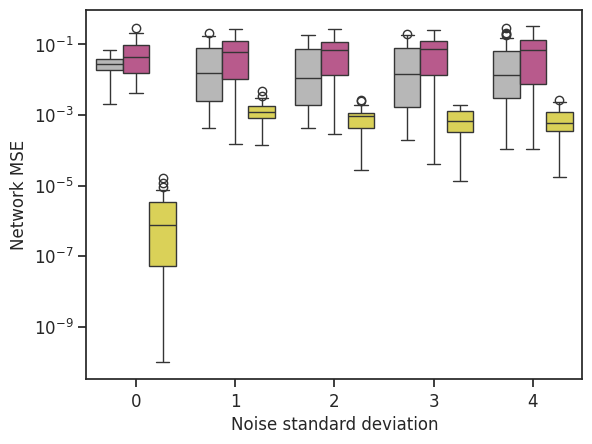

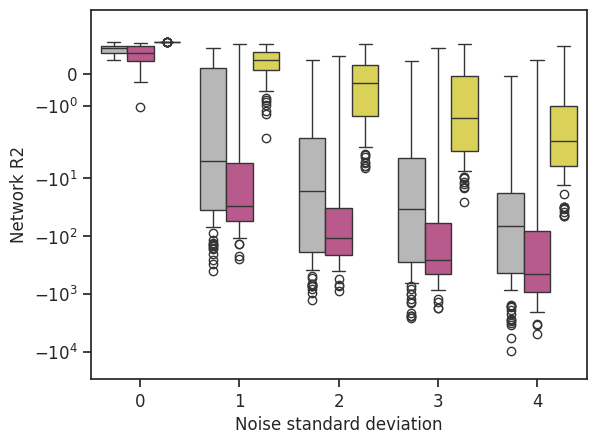

In [22]:
sns.boxplot(data=avg_error[avg_error["model"].isin(["nohill_same_input", "student_same_input", "lm_same_input"])], 
            x="noise_sd", y="MSE", hue="model", palette=models_dict)
plt.legend([], [], frameon=False)
plt.xlabel("Noise standard deviation")
plt.ylabel("Network MSE")
plt.yscale("log")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_MSE_same_inputs_avg_over_nodes_noise_sd.pdf", bbox_inches="tight")
plt.show()

sns.boxplot(data=avg_error[avg_error["model"].isin(["nohill_same_input", "student_same_input", "lm_same_input"])], 
            x="noise_sd", y="R2", hue="model", palette=models_dict)
plt.ylim((-3e4, 2))
plt.xlabel("Noise standard deviation")
plt.yscale("symlog")
plt.ylabel("Network R2")
plt.legend([], [], frameon=False)
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_R2_same_inputs_avg_over_nodes_noise_sd.pdf", bbox_inches="tight")
plt.show()


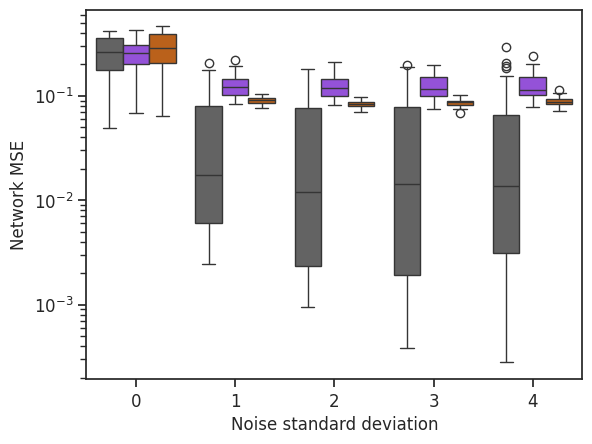

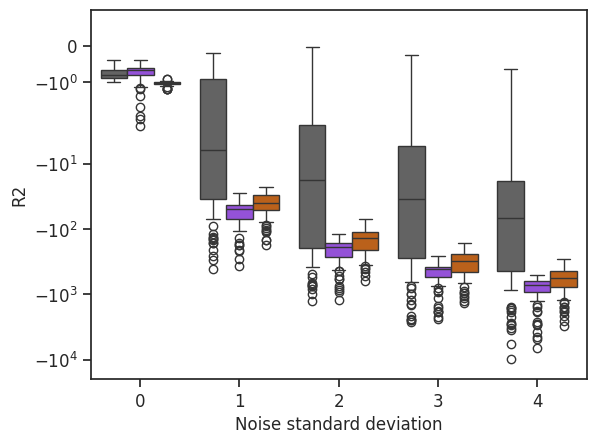

In [23]:
sns.boxplot(data=avg_error[avg_error["model"].isin(["nohill_random_input", "student_random_input", "lm_random_input"])], 
            x="noise_sd", y="MSE", hue="model", palette=models_dict)
plt.legend([], [], frameon=False)
plt.xlabel("Noise standard deviation")
plt.ylabel("Network MSE")
plt.yscale("log")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_MSE_random_inputs_avg_over_nodes_noise_sd.pdf", bbox_inches="tight")
plt.show()

sns.boxplot(data=avg_error[avg_error["model"].isin(["nohill_random_input", "student_random_input", "lm_random_input"])],
            x="noise_sd", y="R2", hue="model", palette=models_dict)
plt.legend([], [], frameon=False)
plt.ylim((-2e4, 1))
plt.xlabel("Noise standard deviation")
plt.yscale("symlog")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_R2_random_inputs_avg_over_nodes_noise_sd.pdf", bbox_inches="tight")
plt.show()

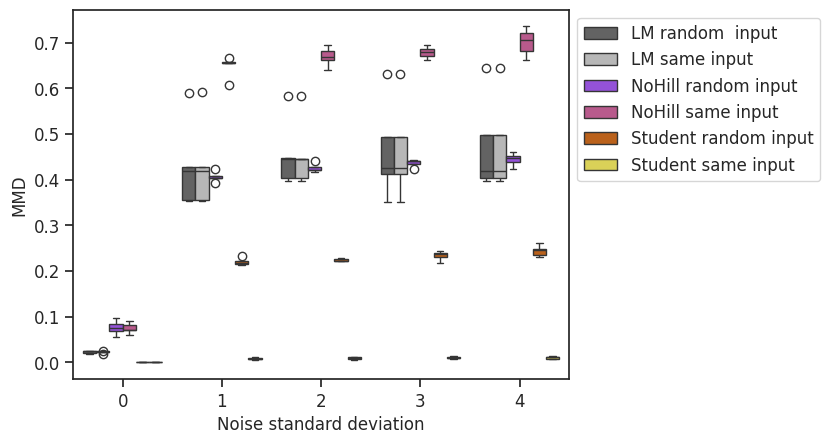

/tmp/ipykernel_2398327/3511446562.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_MMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/3511446562.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_MMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/3511446562.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/C

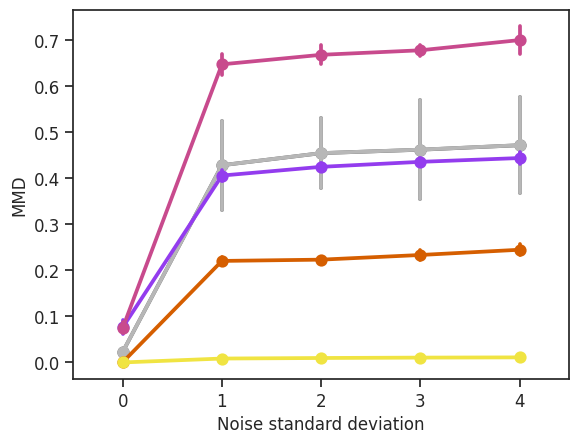

/tmp/ipykernel_2398327/3511446562.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_EMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/3511446562.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_EMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
/tmp/ipykernel_2398327/3511446562.py:26: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(f"/dccstor/ipc1/C

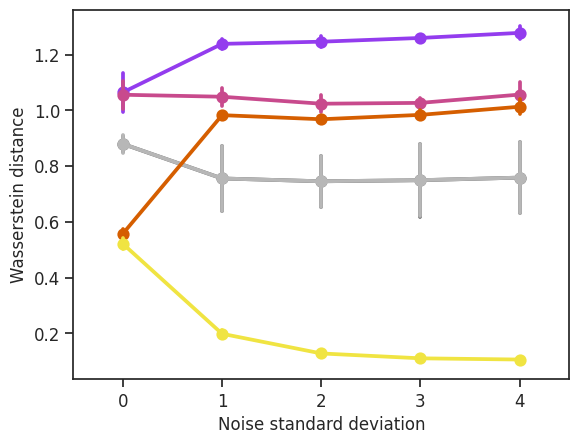

In [24]:
g = sns.boxplot(data=mmd_emd, x="noise_sd", 
            y="MMD", hue="model", palette=models_dict)
g.legend(bbox_to_anchor=(1,1))
new_labels = ["LM random  input", "LM same input", "NoHill random input", "NoHill same input", "Student random input", "Student same input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.xlabel("Noise standard deviation")
# plt.yscale("symlog")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_legend.pdf", bbox_inches="tight")
plt.show()

sns.pointplot(data=mmd_emd, x="noise_sd", 
            y="MMD", hue="model", palette=models_dict, errorbar="sd")
plt.legend([], [], frameon=False)
plt.xlabel("Noise standard deviation")
# plt.yscale("symlog")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_MMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
plt.show()

sns.pointplot(data=mmd_emd, x="noise_sd", 
            y="EMD", hue="model", palette=models_dict, errorbar="sd")
plt.legend([], [], frameon=False)
plt.xlabel("Noise standard deviation")
plt.ylabel("Wasserstein distance")
# plt.yscale("log")
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_EMD_avg_over_nodes_noise_sd_pointplot.pdf", bbox_inches="tight")
plt.show()

In [25]:
mmd_emd

,noise_sd,repeat,model,pred,true,error,sq_err,abs_error,MMD,EMD
0,1,1,lm_random_input,0.613358,0.496933,-0.116425,0.069741,0.211703,5.897618e-01,0.949584
1,1,1,lm_same_input,0.614336,0.496933,-0.117403,0.067808,0.206415,5.907097e-01,0.950640
2,1,1,nohill_random_input,0.458044,0.496933,0.038889,0.129682,0.321784,4.237704e-01,1.259990
3,1,1,nohill_same_input,0.376302,0.496933,0.120631,0.083373,0.245742,6.548360e-01,1.049018
4,1,1,student_random_input,0.560484,0.496933,-0.063551,0.089227,0.257020,2.186689e-01,0.973300
...,...,...,...,...,...,...,...,...,...,...
145,0,5,lm_same_input,0.598720,0.595220,-0.003500,0.025652,0.127620,1.902838e-02,0.847438
146,0,5,nohill_random_input,0.464442,0.595220,0.130779,0.245702,0.379667,7.553025e-02,1.049243
147,0,5,nohill_same_input,0.469686,0.595220,0.125534,0.062627,0.153773,7.178777e-02,1.032789
148,0,5,student_random_input,0.589847,0.595220,0.005373,0.300833,0.398767,3.088762e-04,0.542273


In [26]:
dist_stats = mmd_emd.groupby(["noise_sd", "model"]).mean()[["MMD", "EMD"]].rename(columns={'MMD': "MMD_mean", "EMD": "EMD_mean"})
dist_stats = dist_stats.merge(mmd_emd.groupby(["noise_sd", 
                                               "model"]).std()[["MMD", 
                                                                "EMD"]].rename(columns={'MMD': "MMD_std", 
                                                                                        "EMD": "EMD_std"}), 
                                                                                left_index=True, right_index=True)
dist_stats

MMD_mean  EMD_mean       MMD_std   EMD_std
noise_sd model                                                               
0        lm_random_input       2.308083e-02  0.879598  3.368486e-03  0.028401
         lm_same_input         2.318300e-02  0.879716  2.462571e-03  0.031431
         nohill_random_input   7.637614e-02  1.064407  1.542780e-02  0.069126
         nohill_same_input     7.504829e-02  1.055908  1.192754e-02  0.050733
         student_random_input  5.003785e-04  0.557521  1.549922e-04  0.018563
         student_same_input    5.731980e-07  0.521420  2.209390e-07  0.019718
1        lm_random_input       4.287216e-01  0.755658  9.629743e-02  0.115516
         lm_same_input         4.287686e-01  0.755690  9.691225e-02  0.116247
         nohill_random_input   4.062842e-01  1.238370  1.149445e-02  0.017785
         nohill_same_input     6.480687e-01  1.048786  2.349210e-02  0.032991
         student_random_input  2.207113e-01  0.982733  7.997667e-03  0.012805
         student_same_input    8.503572e-03  0.198779  2.979745e-03  0.011853
2        lm_random_input       4.550061e-01  0.745524  7.557129e-02  0.090857
         lm_same_input         4.550806e-01  0.745594  7.557312e-02  0.090844
         nohill_random_input   4.252393e-01  1.246132  8.832902e-03  0.018685
         nohill_same_input     6.687714e-01  1.023749  2.055193e-02  0.030263
         student_random_input  2.234698e-01  0.967998  3.103936e-03  0.010328
         student_same_input    9.689109e-03  0.128198  2.764728e-03  0.006350
3        lm_random_input       4.624164e-01  0.749363  1.074758e-01  0.130371
         lm_same_input         4.626379e-01  0.749618  1.074230e-01  0.130334
         nohill_random_input   4.360970e-01  1.259562  7.273520e-03  0.009817
         nohill_same_input     6.785873e-01  1.026724  1.209801e-02  0.017669
         student_random_input  2.336076e-01  0.983744  1.000328e-02  0.015858
         student_same_input    1.053231e-02  0.110698  3.300094e-03  0.011752
4        lm_random_input       4.722223e-01  0.758694  1.038843e-01  0.127755
         lm_same_input         4.723506e-01  0.758855  1.038903e-01  0.127772
         nohill_random_input   4.443685e-01  1.277778  1.345352e-02  0.023029
         nohill_same_input     7.007758e-01  1.056521  2.964325e-02  0.044906
         student_random_input  2.450075e-01  1.012948  1.163678e-02  0.027075
         student_same_input    1.102527e-02  0.106328  2.716012e-03  0.010439

In [27]:
error_stats = avg_error.groupby(["noise_sd", "model"]).mean()[["MSE", "R2"]].rename(columns={'MSE': "MSE_mean", "R2": "R2_mean"})
error_stats = error_stats.merge(avg_error.groupby(["noise_sd", 
                                                   "model"]).std()[["MSE", 
                                                                    "R2"]].rename(columns={'MSE': "MSE_std", 
                                                                                            "R2": "R2_std"}), 
                                left_index=True, right_index=True)
error_stats

MSE_mean      R2_mean   MSE_std       R2_std
noise_sd model                                                             
0        lm_random_input       0.259548    -0.772721  0.112404     0.158585
         lm_same_input         0.029056     0.763797  0.016436     0.154603
         nohill_random_input   0.244993    -0.794338  0.086690     0.388851
         nohill_same_input     0.065027     0.580714  0.063091     0.358248
         student_random_input  0.290650    -1.030780  0.117239     0.054973
         student_same_input    0.000002     0.999975  0.000003     0.000054
1        lm_random_input       0.045226   -43.015206  0.054240    80.438771
         lm_same_input         0.043038   -42.124399  0.055269    80.659354
         nohill_random_input   0.127100   -71.977676  0.031579    62.072348
         nohill_same_input     0.083097   -40.108162  0.078985    48.110909
         student_random_input  0.091189   -49.625998  0.007499    31.752195
         student_same_input    0.001373     0.271835  0.000875     0.596008
2        lm_random_input       0.043341  -164.314473  0.055669   286.439020
         lm_same_input         0.043040  -163.820303  0.055827   286.489525
         nohill_random_input   0.123654  -274.564712  0.029245   217.745798
         nohill_same_input     0.080218  -157.046579  0.071431   177.573261
         student_random_input  0.084335  -183.276300  0.006015   113.824494
         student_same_input    0.000885    -0.950586  0.000554     1.843289
3        lm_random_input       0.044282  -370.261211  0.059043   690.904876
         lm_same_input         0.044227  -370.176668  0.059098   691.247269
         nohill_random_input   0.125319  -601.722608  0.029376   485.013139
         nohill_same_input     0.080914  -335.791901  0.072727   380.132729
         student_random_input  0.085604  -408.364059  0.006170   274.536007
         student_same_input    0.000791    -3.008133  0.000559     4.708194
4        lm_random_input       0.045305  -728.322527  0.064437  1583.721077
         lm_same_input         0.045295  -728.468264  0.064470  1584.333996
         nohill_random_input   0.128538 -1158.083803  0.035426  1157.567862
         nohill_same_input     0.085878  -674.356968  0.080980   894.446893
         student_random_input  0.088894  -767.119022  0.007980   561.020422
         student_same_input    0.000774    -7.457493  0.000623    12.373114

In [28]:
all_stats = pd.concat([dist_stats, error_stats], axis=1)
all_stats = all_stats[sorted(all_stats.columns)]
metrics = ["EMD", "MMD", "MSE", "R2"]
for m in metrics:
    all_stats[m] = round(all_stats[f"{m}_mean"], 3).astype(str) + "±" + round(all_stats[f"{m}_std"], 3).astype(str)
all_stats = all_stats.loc[:, all_stats.columns.isin(metrics)].reset_index()
all_stats[["model", "input", "del"]] = [model.split("_") for model in all_stats["model"]]
all_stats = all_stats.drop("del", axis=1)
all_stats = all_stats[["model","input", "noise_sd", "MSE", "R2", "EMD", "MMD"]]
all_stats = all_stats.sort_values(["noise_sd", "input", "model"]).reset_index(drop=True)
all_stats.to_csv("/dccstor/ipc1/CAR/BFN/Model/Noise/Output_stats.csv")
all_stats

,model,input,noise_sd,MSE,R2,EMD,MMD
0,lm,random,0,0.26±0.112,-0.773±0.159,0.88±0.028,0.023±0.003
1,nohill,random,0,0.245±0.087,-0.794±0.389,1.064±0.069,0.076±0.015
2,student,random,0,0.291±0.117,-1.031±0.055,0.558±0.019,0.001±0.0
3,lm,same,0,0.029±0.016,0.764±0.155,0.88±0.031,0.023±0.002
4,nohill,same,0,0.065±0.063,0.581±0.358,1.056±0.051,0.075±0.012
5,student,same,0,0.0±0.0,1.0±0.0,0.521±0.02,0.0±0.0
6,lm,random,1,0.045±0.054,-43.015±80.439,0.756±0.116,0.429±0.096
7,nohill,random,1,0.127±0.032,-71.978±62.072,1.238±0.018,0.406±0.011
8,student,random,1,0.091±0.007,-49.626±31.752,0.983±0.013,0.221±0.008
9,lm,same,1,0.043±0.055,-42.124±80.659,0.756±0.116,0.429±0.097


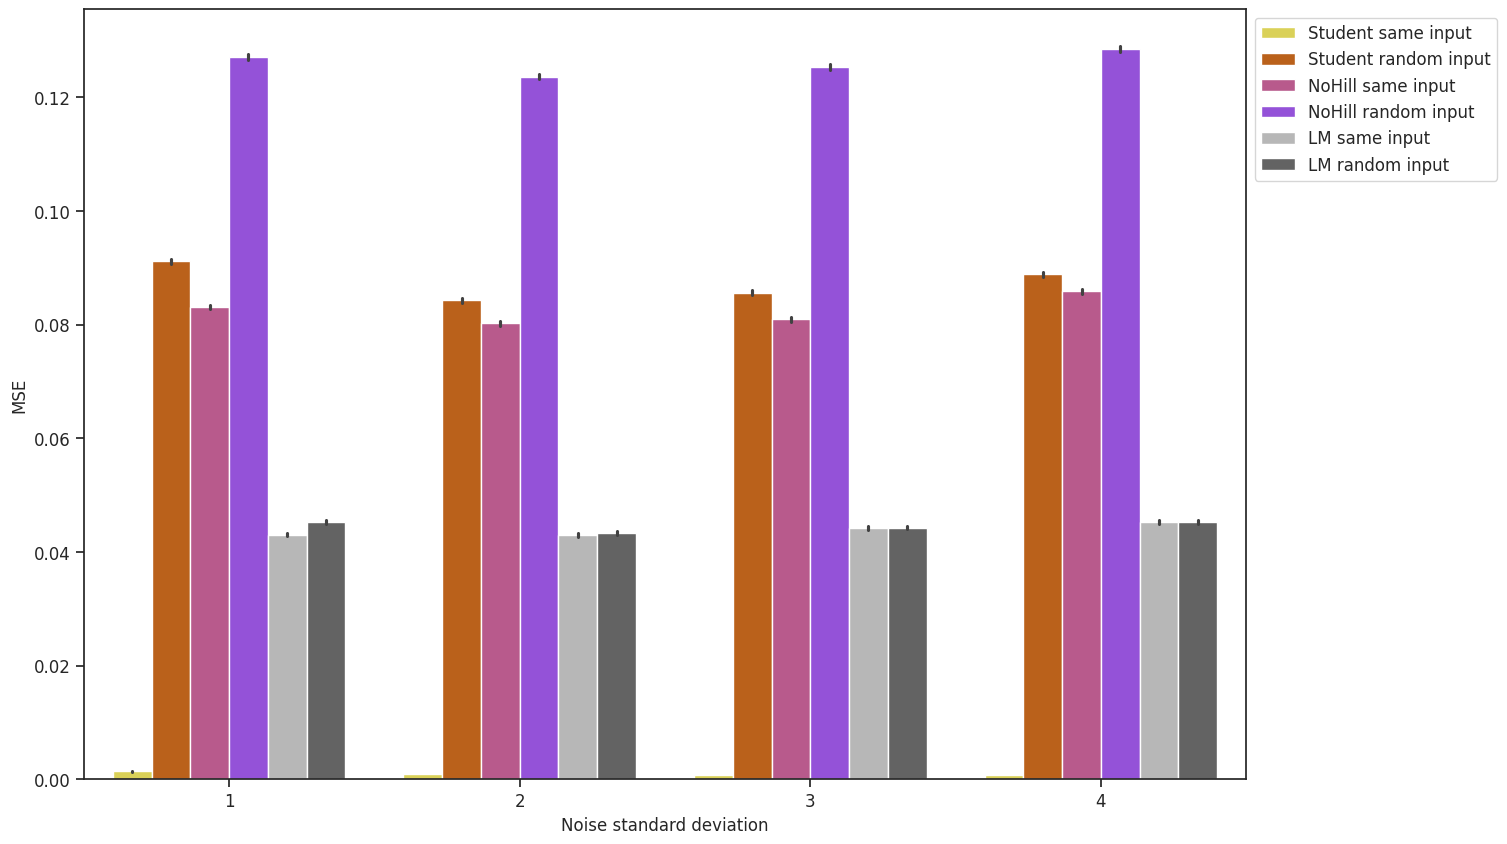

In [29]:
plt.figure(figsize=(15,10))
g = sns.barplot(data=df, x="noise_sd", y="sq_err", hue="model", palette=models_dict)
plt.xlabel("Noise standard deviation")
plt.ylabel("MSE")
plt.legend(bbox_to_anchor=(1,1))
new_labels = ["Student same input", "Student random input", "NoHill same input", "NoHill random input", "LM same input", "LM random input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_SQE_noise_sd_bar.pdf", bbox_inches="tight")
plt.show()

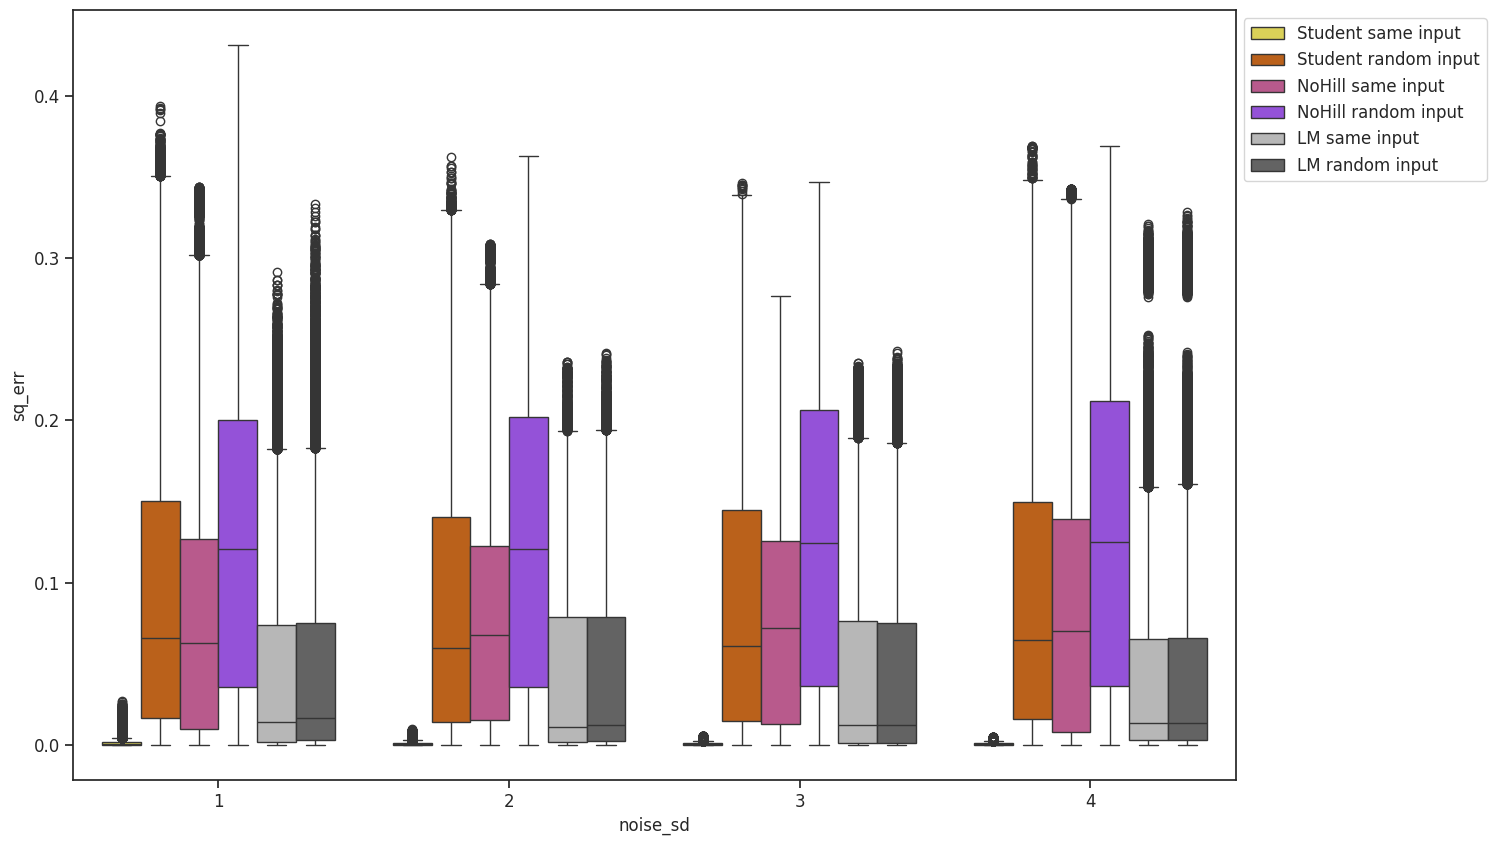

In [30]:
plt.figure(figsize=(15,10))
g = sns.boxplot(data=df, x="noise_sd", y="sq_err", hue="model", palette=models_dict)
plt.legend(bbox_to_anchor=(1,1))
new_labels = ["Student same input", "Student random input", "NoHill same input", "NoHill random input", "LM same input", "LM random input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)
plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_SQE_noise_sd_box.pdf", bbox_inches="tight")
plt.show()

AttributeError: 'Legend' object has no attribute 'legend_'

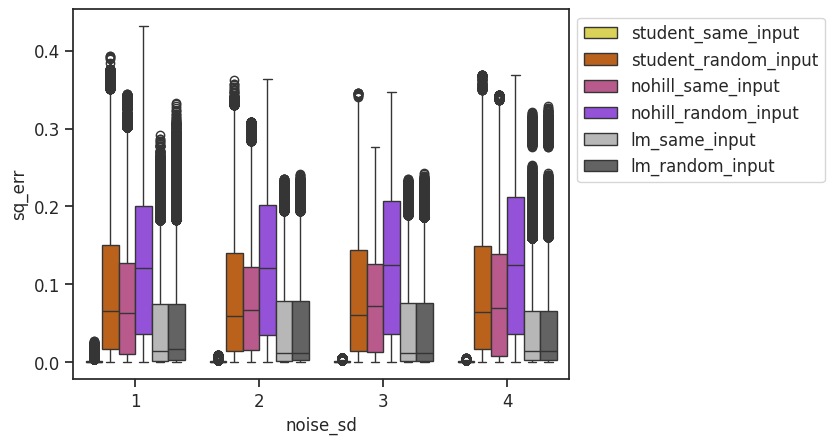

In [31]:
for n in df["marker"].unique():
    sel_df = df[df["marker"]==n]
    g = sns.boxplot(data=df, x="noise_sd", y="sq_err", hue="model", palette=models_dict)
    plt.legend(bbox_to_anchor=(1,1))
    new_labels = ["Student same input", "Student random input", "NoHill same input", "NoHill random input", "LM same input", "LM random input"]
    for t, l in zip(g.legend_.texts, new_labels):
        t.set_text(l)
    plt.title(n)
    plt.savefig(f"/dccstor/ipc1/CAR/BFN/Figures/Noise_{experiment_name}_SQE_noise_sd_{n}_box.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
df.max()

In [ ]:
g=sns.barplot(data=df, x="noise_sd", y="sq_err", hue="model", palette=models_dict)
new_labels = ["Student same input", "Student random input", "NoHill same input", "NoHill random input", "LM same input", "LM random input"]
for t, l in zip(g.legend_.texts, new_labels):
    t.set_text(l)